# Unemployment Analysis with Python

## OASIS INFOBYTE Data Science Internship — Task 2

In [2]:
# Load the unemployment dataset

df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display the first 5 rows of the dataset

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Check the number of rows and columns

print("Shape of the dataset:", df.shape)

Shape of the dataset: (768, 7)


In [5]:
# Check column names and data types

print("Column names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Column names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [6]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [7]:
# Display basic statistics of numerical columns

df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [8]:
# Clean column names

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [9]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df["Date"].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [10]:
# Check the cleaned dataset

print(df.head())
print("\nData types after cleaning:")
print(df.dtypes)

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

Data types after cleaning:
Region                                             object
Date                           

In [11]:
# Calculate average unemployment rate for each region

region_average = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

print(region_average)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


In [12]:
# Get the top 10 regions with the highest average unemployment rate

top_10_regions = region_average.head(10)

print(top_10_regions)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


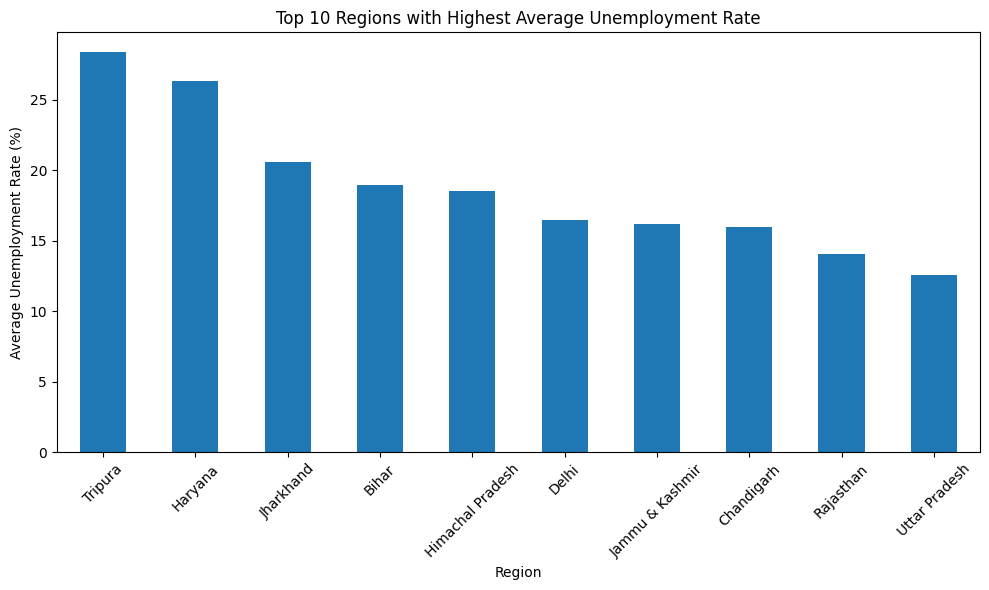

In [13]:
# Plot the top 10 regions with the highest average unemployment rate

plt.figure(figsize=(10, 6))

top_10_regions.plot(kind="bar")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
# Calculate average unemployment rate by month

monthly_average = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

print(monthly_average)

Date
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64


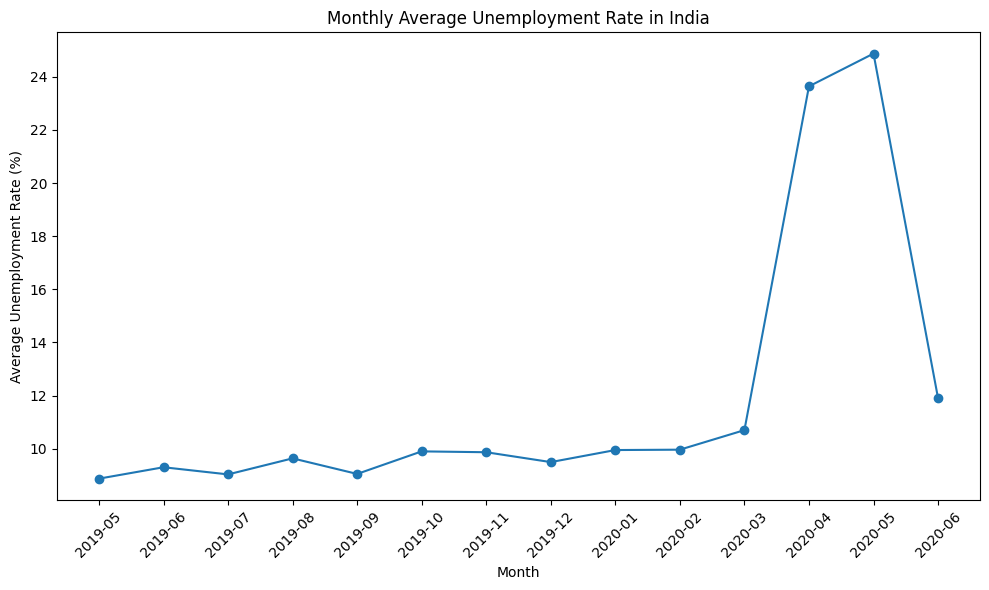

In [15]:
# Plot monthly average unemployment rate

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_average.index.astype(str),
    monthly_average.values,
    marker="o"
)

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
# Select 3 major regions for time-series analysis

selected_regions = ["Maharashtra", "Tamil Nadu", "Karnataka"]

print("Selected regions:", selected_regions)

Selected regions: ['Maharashtra', 'Tamil Nadu', 'Karnataka']


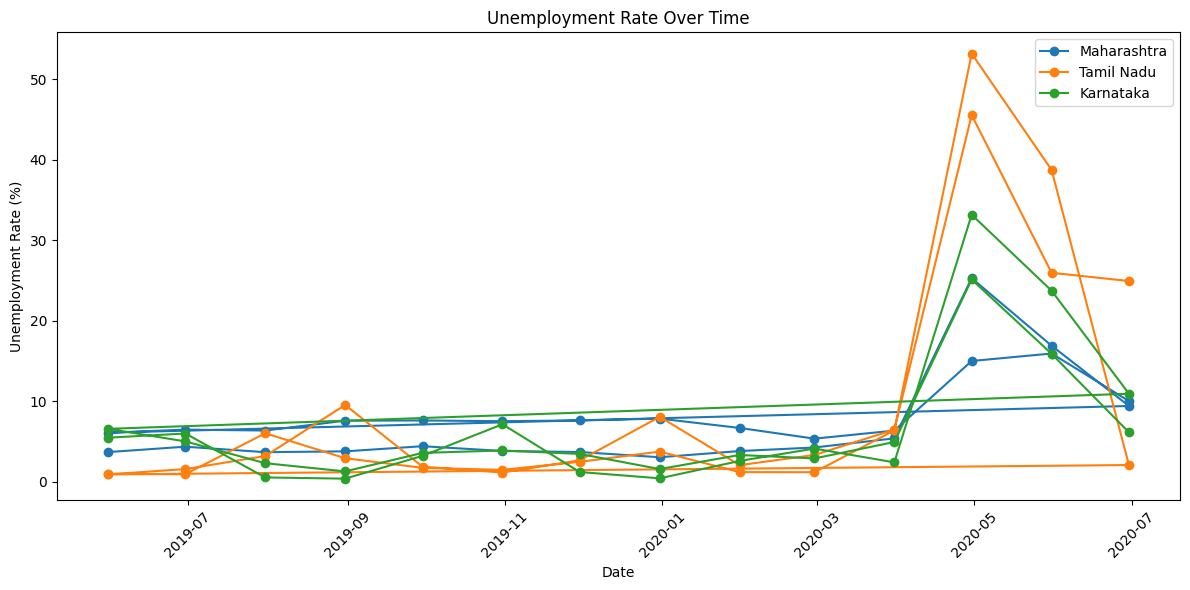

In [17]:
# Plot unemployment rate over time for 3 selected regions

plt.figure(figsize=(12, 6))

for region in selected_regions:
    region_data = df[df["Region"] == region]
    
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

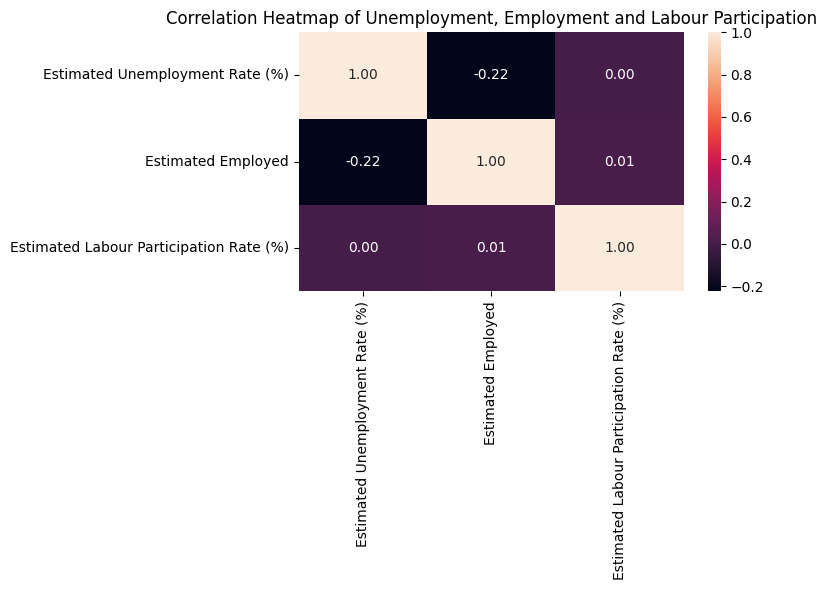

In [18]:
# Create a correlation heatmap

correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Unemployment, Employment and Labour Participation")
plt.tight_layout()

plt.show()

In [19]:
# Compare unemployment before and after COVID-19

pre_covid = df[df["Date"] < "2020-03-01"]
post_covid = df[df["Date"] >= "2020-03-01"]

pre_covid_average = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_covid_average = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID average unemployment rate:",
      round(pre_covid_average, 2), "%")

print("Post-COVID average unemployment rate:",
      round(post_covid_average, 2), "%")

Pre-COVID average unemployment rate: 9.51 %
Post-COVID average unemployment rate: 17.77 %


## Observations

- The region-wise analysis shows that unemployment rates vary considerably across different regions of India.
- The top 10 analysis highlights the regions with the highest average unemployment rates during the period covered by the dataset.
- The monthly trend shows that unemployment changed significantly over time.
- The time-series comparison of Maharashtra, Tamil Nadu, and Karnataka shows differences in unemployment patterns between regions.
- The correlation heatmap helps us understand the relationship between unemployment, employment, and labour participation rates.
- The pre-COVID and post-COVID comparison shows a change in the average unemployment rate after the COVID-19 period began.

## Conclusion

This analysis explored unemployment trends in India using regional and time-based data.

The analysis showed that unemployment rates varied across regions and changed over time. The top 10 regional analysis identified areas with relatively higher average unemployment rates.

The time-series analysis of Maharashtra, Tamil Nadu, and Karnataka showed different unemployment patterns across the three regions. The correlation heatmap helped examine the relationships between unemployment, employment, and labour participation.

The pre-COVID and post-COVID comparison also showed a change in the average unemployment rate during the COVID-19 period.

Overall, the analysis provides a better understanding of regional and temporal unemployment patterns in India.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [5]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Remove rows with missing values
df = df.dropna()

print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum())

Data cleaned successfully!
Shape after cleaning: (740, 7)
Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [6]:
# Descriptive statistics
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [7]:
# Average unemployment rate by region
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

print("Average Unemployment Rate by Region:")
print(region_avg)

Average Unemployment Rate by Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


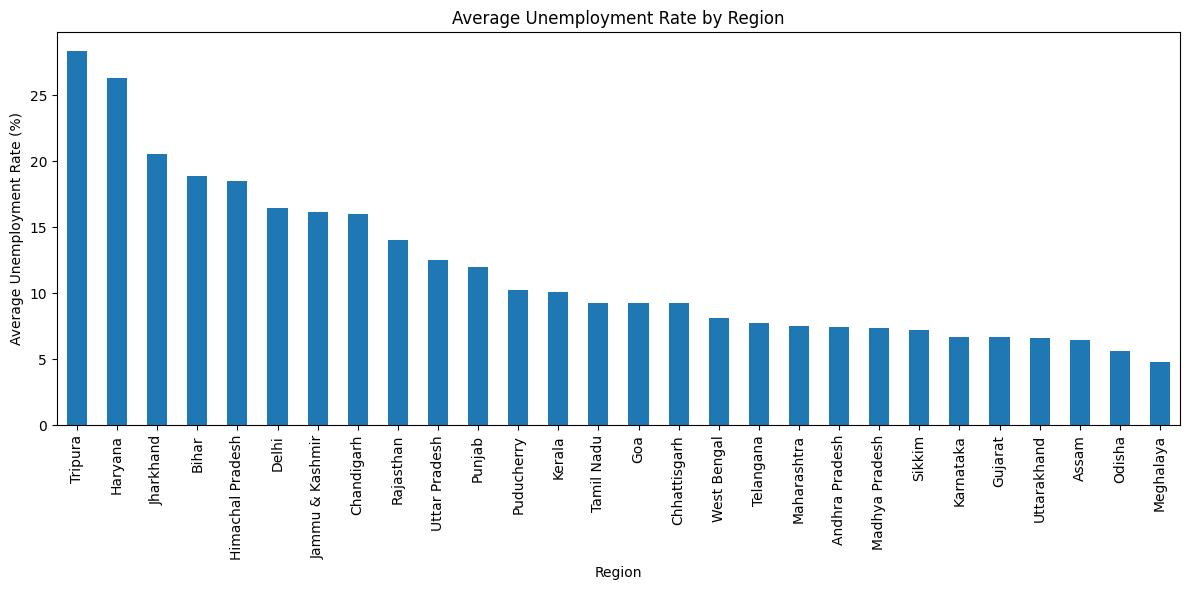

In [8]:
# Region-wise average unemployment rate

plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Average Unemployment Rate by Region")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Observation

The regional analysis shows significant differences in unemployment rates across India. Tripura has the highest average unemployment rate, followed by Haryana and Jharkhand. Meghalaya and Odisha have comparatively lower average unemployment rates in this dataset. This indicates that unemployment varied considerably across different regions.

### Observation
Tripura has the highest average unemployment rate, followed by Haryana and Jharkhand. Unemployment varies considerably across regions.

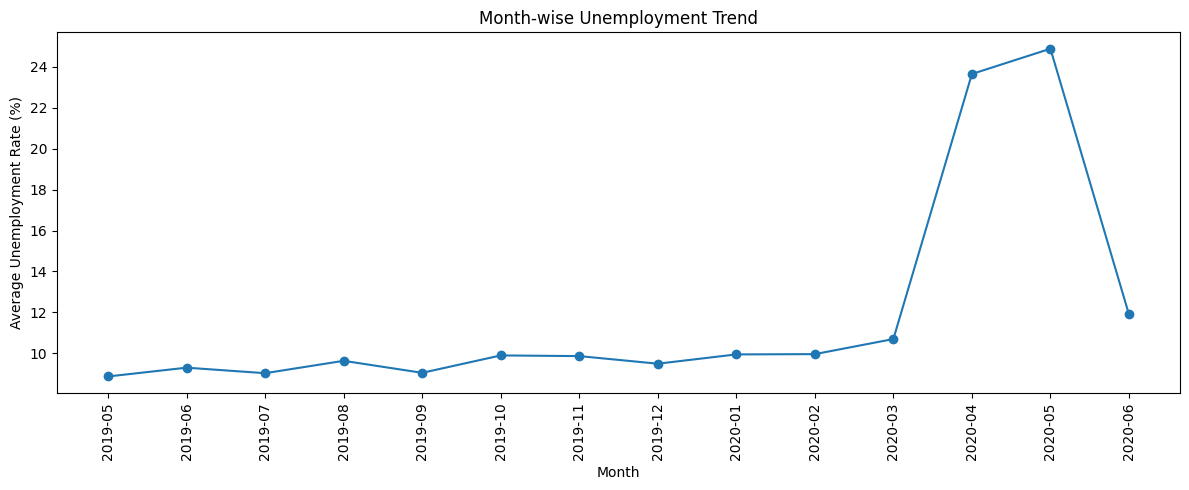

In [10]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Month-wise Unemployment Trend")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
The unemployment rate changes considerably over time, with a noticeable rise during the COVID-19 period.

major_regions = ["Haryana", "Tripura", "Bihar"]

plt.figure(figsize=(12,6))

for region in major_regions:
    temp = df[df["Region"] == region]
    plt.plot(temp["Date"], temp["Estimated Unemployment Rate (%)"], label=region)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time — Major Regions")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
The three selected regions show different unemployment patterns over time. Unemployment increased sharply around the COVID-19 period.

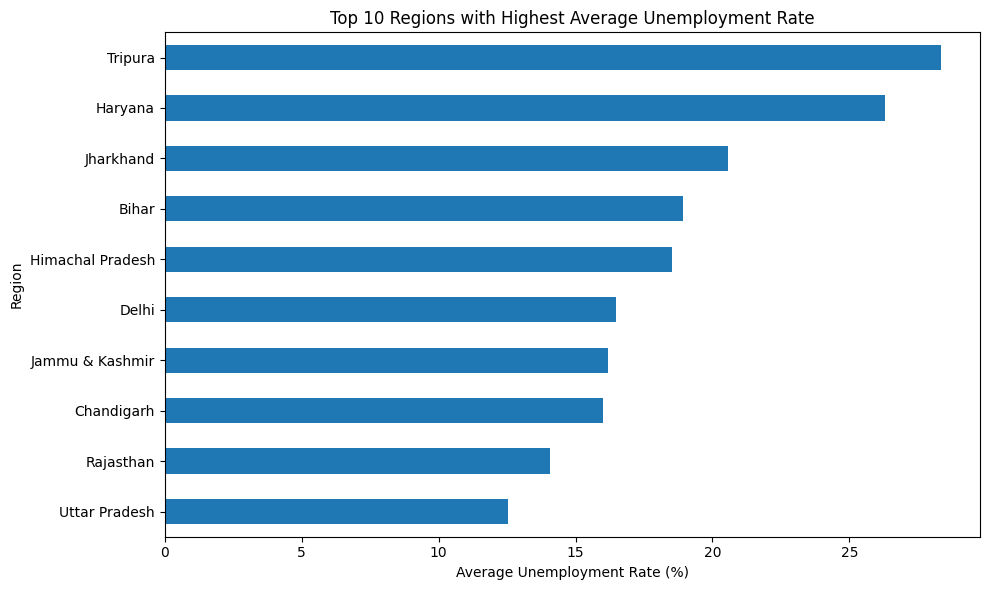

In [12]:
top10 = region_avg.head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind="barh")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.tight_layout()
plt.show()

### Observation
The top 10 regions have the highest average unemployment rates in the dataset, with Tripura and Haryana among the highest.

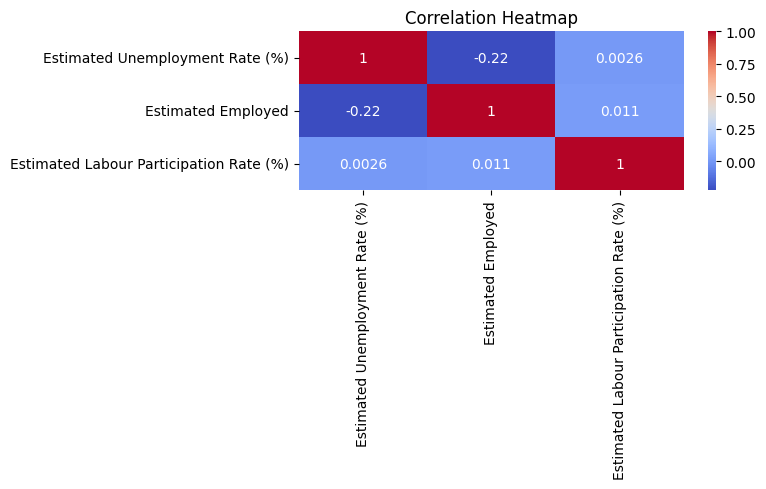

In [14]:
import seaborn as sns

corr = df[
    ["Estimated Unemployment Rate (%)",
     "Estimated Employed",
     "Estimated Labour Participation Rate (%)"]
].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation
The heatmap shows the relationships between unemployment rate, employment, and labour participation rate.

       Period  Average Unemployment Rate
0   Pre-COVID                   9.509534
1  Post-COVID                  17.774363


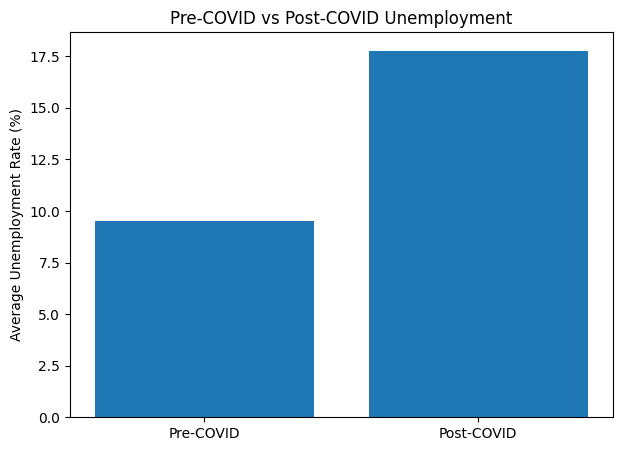

In [15]:
pre_covid = df[df["Date"] < "2020-03-01"]
post_covid = df[df["Date"] >= "2020-03-01"]

comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

print(comparison)

plt.figure(figsize=(7,5))
plt.bar(comparison["Period"], comparison["Average Unemployment Rate"])
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Pre-COVID vs Post-COVID Unemployment")
plt.show()

### Observation
The comparison shows how unemployment changed after the beginning of the COVID-19 period. The post-COVID period shows a higher average unemployment rate than the pre-COVID period in this analysis.

# Conclusion

This analysis explored unemployment trends across different regions and time periods in India.

The regional analysis showed significant differences in average unemployment rates. The time-series analysis highlighted changes in unemployment over time, particularly around the COVID-19 period.

The correlation analysis examined the relationship between unemployment, employment, and labour participation. The pre-COVID and post-COVID comparison showed the impact of the pandemic period on unemployment.

Overall, the analysis provides a better understanding of regional and temporal unemployment patterns in India.